In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os, h5py
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import tensorflow as tf
tf.config.experimental.set_memory_growth(tf.config.list_physical_devices(device_type="GPU")[0], True)
from deepsphere.healpy_layers import HealpySmoothing

os.environ["OMP_NUM_THREADS"] = str(len(os.sched_getaffinity(0)))
import healpy as hp

from msfm.utils import files, redshift, clustering, scales, input_output
from msfm.fiducial_pipeline import FiducialPipeline

# setup

In [3]:
conf = "/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v10/linear_bias.yaml"
conf = files.load_config(conf)
hp_datapath = "/global/u2/a/athomsen/multiprobe-simulation-forward-model/data/healpy_data"

dlss_conf = "/global/homes/a/athomsen/y3-deep-lss/configs/v10/combined/dlss_config.yaml"
dlss_conf = input_output.read_yaml(dlss_conf)
# dlss_conf = {
#     "scale_cuts" : {
#           "n_sigma_support": 3,
#           "arcmin": True,
#           "lensing": {
#             # 6 Mpc/h transverse comoving scale -> arcmin
#             "theta_fwhm": [22.1, 15.1, 11.2, 9.4]
#           },
#         "clustering" : {
#             # 16 Mpc/h transverse comoving scale -> arcmin
#             "theta_fwhm": [65.1, 44.5, 34.1, 28.5]
#         },
#     }
# }

n_side = conf["analysis"]["n_side"]
n_pix = conf["analysis"]["n_pix"]
l_min_global = 20
l_max_global = 1535
data_vec_pix, patches_pix_dict, corresponding_pix_dict, _ = files.load_pixel_file(conf)

# fiducial values
Aia = conf["analysis"]["fiducial"]["Aia"]
n_Aia = conf["analysis"]["fiducial"]["n_Aia"]

bg = conf["analysis"]["fiducial"]["bg"]
n_bg = conf["analysis"]["fiducial"]["n_bg"]

z0 = conf["analysis"]["modelling"]["z0"]

# metacal
metacal_bins = conf["survey"]["lensing"]["z_bins"]
n_z_metacal = len(metacal_bins)
tomo_z_metacal, tomo_nz_metacal = files.load_redshift_distributions("metacal", conf)
tomo_Aia = redshift.get_tomo_amplitudes(Aia, n_Aia, tomo_z_metacal, tomo_nz_metacal, z0)

# maglim
maglim_bins = conf["survey"]["lensing"]["z_bins"]
n_z_maglim = len(maglim_bins)
tomo_z_maglim, tomo_nz_maglim = files.load_redshift_distributions("maglim", conf)
tomo_n_gal_maglim = np.array(conf["survey"]["clustering"]["n_gal"]) * hp.nside2pixarea(n_side, degrees=True)
tomo_bg = redshift.get_tomo_amplitudes(bg, n_bg, tomo_z_maglim, tomo_nz_maglim, z0)

n_z = n_z_metacal + n_z_maglim

# scales
# theta_fwhms = [22.1, 15.1, 11.2, 9.4] + [65.1, 44.5, 34.1, 28.5]
theta_fwhms = dlss_conf["scale_cuts"]["lensing"]["theta_fwhm"] + dlss_conf["scale_cuts"]["clustering"]["theta_fwhm"]
l_maxs_naive = list(scales.angle_to_ell(np.array(theta_fwhms), arcmin=True).astype(int))

25-02-06 12:16:05     files.py INF   Loaded the pixel file /global/u2/a/athomsen/multiprobe-simulation-forward-model/data/DESY3_pixels_v11_fiducial_512.h5 


# load the full sky maps

In [4]:
%%time
# fidu_dir = "/global/cfs/cdirs/des/cosmogrid/v11desy3/fiducial/cosmo_fiducial"
# fidu_dir = "/pscratch/sd/a/athomsen/v11desy3/fiducial/cosmo_fiducial"
# fidu_dir = "/global/cfs/cdirs/des/cosmogrid/v11desy3/CosmoGrid/v11desy3/fiducial/cosmo_fiducial"
fidu_dir = "/global/cfs/cdirs/des/cosmogrid/processed/v11desy3/CosmoGrid/bary/fiducial/cosmo_fiducial"

n_examples = 10
# n_examples = 2

wl = []
gc = []
for i in tqdm(range(n_examples)):
    with h5py.File(os.path.join(fidu_dir, f"perm_{i:04d}", "projected_probes_maps_v11dmb.h5"), "r") as f:
        kg = []
        ia = []
        for z_bin in metacal_bins:
            kg.append(hp.ud_grade(f[f"map/kg/{z_bin}"], n_side))
            ia.append(hp.ud_grade(f[f"map/ia/{z_bin}"], n_side))
        kg = np.stack(kg, axis=-1)
        ia = np.stack(ia, axis=-1)
        
        wl.append(kg + tomo_Aia * ia)

        dg = []
        for z_bin in maglim_bins:
            dg.append(hp.ud_grade(f[f"map/dg/{z_bin}"], n_side))
        dg = np.stack(dg, axis=-1)
        
        gc.append(clustering.galaxy_density_to_count(tomo_n_gal_maglim, (dg - np.mean(dg))/np.mean(dg), tomo_bg, nest=False))

wl = np.stack(wl, axis=0)
gc = np.stack(gc, axis=0)

fidu_maps = np.concatenate([wl, gc], axis=-1)

print(fidu_maps.shape)

100%|██████████| 10/10 [10:19<00:00, 61.94s/it]


(10, 3145728, 8)
CPU times: user 8min 40s, sys: 1min 37s, total: 10min 17s
Wall time: 10min 20s


# compute the $C_\ell$ and $\ell_\text{threshold}$

In [5]:
thresholds = [
    0.01,
    0.1,
]

mpcs = [
    (4, 16),
    (6, 20),
    (8, 24),
    (10, 28),
    (12, 32),
]

theta_fwhms = [
    # metacal 4 Mpc/h, maglim 16 Mpc/h
    [14.75582447, 10.06556388, 7.4939301, 6.28738821] + [65.10123532, 44.45232207, 34.06191548, 28.52162382],
    # metacal 6 Mpc/h, maglim 20 Mpc/h
    [22.13373671, 15.09834582, 11.24089514, 9.43108231] + [81.37654415, 55.56540258, 42.57739435, 35.65202978],
    # metacal 8 Mpc/h, maglim 24 Mpc/h
    [29.51164894, 20.13112776, 14.98786019, 12.57477642] + [97.65185298, 66.6784831, 51.09287323, 42.78243574],
    # metacal 10 Mpc/h, maglim 28 Mpc/h
    [36.88956118, 25.1639097, 18.73482524, 15.71847052] + [113.92716181, 77.79156362, 59.6083521, 49.91284169],
    # metacal 12 Mpc/h, maglim 32 Mpc/h
    [44.26747341, 30.19669164, 22.48179029, 18.86216463] + [130.20247064, 88.90464413, 68.12383097, 57.04324765],
]

raw_cls = np.zeros((n_examples, l_max_global+1, n_z))
for i, fidu_map in enumerate(fidu_maps):
    for j in range(fidu_map.shape[-1]):
        raw_cls[i,:,j] = hp.anafast(fidu_map[:,j], lmax=l_max_global, pol=False, datapath=hp_datapath, use_pixel_weights=True)
        
mean_cls = np.mean(raw_cls, axis=0)
smooth_cls = np.zeros_like(mean_cls)
l = np.arange(0, l_max_global+1)

with np.printoptions(precision=4, suppress=False, formatter={'float': '{:0.4e}'.format}):
    for mpc, theta_fwhm in zip(mpcs, theta_fwhms):
        # theta_fwhm = np.array(theta_fwhm)
        print(f"\nmpc/h = {mpc}")
        print(f"theta_fwhm = {theta_fwhm}")
        l_maxs_naive = list(scales.angle_to_ell(np.array(theta_fwhm), arcmin=True).astype(int))
        
        for threshold in thresholds:
            l_maxs_thresh = []
            cl_noise_levels = []
            sigmas = []
            sigmas_naive = []
            for i in range(len(theta_fwhm)):
                # smoothing
                high_pass_fac_cls = scales.gaussian_high_pass_factor_alm(l, l_min=30)**2
                low_pass_fac_cls = scales.gaussian_low_pass_factor_alm(l, theta_fwhm=theta_fwhm[i], arcmin=True)**2
                smooth_cls[:,i] = high_pass_fac_cls * low_pass_fac_cls * mean_cls[:,i]

                # determine the l_max when the Cls are suppressed by as much as the threshold
                try:
                    l_max = l[low_pass_fac_cls < threshold][0]
                except IndexError:
                    l_max = l_max_global
                l_maxs_thresh.append(l_max)

                # evaluate the full sky Cls at that l_max 
                cl_noise_level = smooth_cls[l_max,i]
                cl_noise_levels.append(cl_noise_level)

                # convert to a sigma of white Gaussian noise
                sigma = np.sqrt(cl_noise_level / hp.nside2pixarea(n_side))
                sigmas.append(sigma)

                # sigmas_naive.append(np.sqrt(smooth_cls[l_maxs_naive[i],i] / hp.nside2pixarea(n_side)))

            l_maxs_thresh = np.array(l_maxs_thresh)
            cl_noise_levels = np.array(cl_noise_levels)
            sigmas = np.array(sigmas)

            print(f"\nthreshold = {threshold*100}%")
            print(f"l_maxs_naive = {np.array(l_maxs_naive)}")
            print(f"l_maxs_thresh = {l_maxs_thresh}")
            print(f"cl_noise_levels = {cl_noise_levels}")
            print(f"sigmas = {sigmas}")

        print(f"\nthreshold = naive")
        print(f"l_maxs_naive = {np.array(l_maxs_naive)}")
        print(f"sigmas = {np.array(sigmas_naive)}")


mpc/h = (4, 16)
theta_fwhm = [14.75582447, 10.06556388, 7.4939301, 6.28738821, 65.10123532, 44.45232207, 34.06191548, 28.52162382]

threshold = 1.0%
l_maxs_naive = [ 731 1072 1441 1717  165  242  317  378]
l_maxs_thresh = [1177 1535 1535 1535  267  391  510  609]
cl_noise_levels = [9.3769e-14 6.0030e-13 8.2415e-12 2.2716e-11 1.0883e-06 1.7185e-07
 8.8562e-08 7.1930e-08]
sigmas = [1.5321e-04 3.8765e-04 1.4363e-03 2.3846e-03 5.2194e-01 2.0741e-01
 1.4889e-01 1.3419e-01]

threshold = 10.0%
l_maxs_naive = [ 731 1072 1441 1717  165  242  317  378]
l_maxs_thresh = [ 832 1220 1535 1535  189  276  361  431]
cl_noise_levels = [2.0095e-12 3.3605e-12 8.2415e-12 2.2716e-11 1.7298e-05 2.8110e-06
 1.5543e-06 1.3105e-06]
sigmas = [7.0925e-04 9.1719e-04 1.4363e-03 2.3846e-03 2.0809e+00 8.3885e-01
 6.2377e-01 5.7275e-01]

threshold = naive
l_maxs_naive = [ 731 1072 1441 1717  165  242  317  378]
sigmas = []

mpc/h = (6, 20)
theta_fwhm = [22.13373671, 15.09834582, 11.24089514, 9.43108231, 81.37654415, 

In [9]:
thresholds = [
    0.01,
    0.1,
]

raw_cls = np.zeros((n_examples, l_max_global+1, n_z))
for i, fidu_map in enumerate(fidu_maps):
    for j in range(fidu_map.shape[-1]):
        raw_cls[i,:,j] = hp.anafast(fidu_map[:,j], lmax=l_max_global, pol=False, datapath=hp_datapath, use_pixel_weights=True)

mean_cls = np.mean(raw_cls, axis=0)
smooth_cls = np.zeros_like(mean_cls)
l = np.arange(0, l_max_global+1)
        
with np.printoptions(precision=4, suppress=False, formatter={'float': '{:0.4e}'.format}):
    theta_fwhm = theta_fwhms
    print(f"\ntheta_fwhm = {theta_fwhm}")
    l_maxs_naive = list(scales.angle_to_ell(np.array(theta_fwhm), arcmin=True).astype(int))

    for threshold in thresholds:
        l_maxs_thresh = []
        cl_noise_levels = []
        sigmas = []
        sigmas_naive = []
        for i in range(len(theta_fwhm)):
            # smoothing
            high_pass_fac_cls = scales.gaussian_high_pass_factor_alm(l, l_min=30)**2
            low_pass_fac_cls = scales.gaussian_low_pass_factor_alm(l, theta_fwhm=theta_fwhm[i], arcmin=True)**2
                        
            smooth_cls[:,i] = high_pass_fac_cls * low_pass_fac_cls * mean_cls[:,i]

            # determine the l_max when the Cls are suppressed by as much as the threshold
            try:
                l_max = l[low_pass_fac_cls < threshold][0]
            except IndexError:
                l_max = l_max_global
            l_maxs_thresh.append(l_max)

            # evaluate the full sky Cls at that l_max 
            cl_noise_level = smooth_cls[l_max,i]
            cl_noise_levels.append(cl_noise_level)

            # convert to a sigma of white Gaussian noise
            sigma = np.sqrt(cl_noise_level / hp.nside2pixarea(n_side))
            sigmas.append(sigma)

            sigmas_naive.append(np.sqrt(smooth_cls[l_maxs_naive[i],i] / hp.nside2pixarea(n_side)))

        l_maxs_thresh = np.array(l_maxs_thresh)
        cl_noise_levels = np.array(cl_noise_levels)
        sigmas = np.array(sigmas)

        print(f"\nthreshold = {threshold*100}%")
        print(f"l_maxs_naive = {np.array(l_maxs_naive)}")
        print(f"l_maxs_thresh = {l_maxs_thresh}")
        print(f"cl_noise_levels = {cl_noise_levels}")
        print(f"sigmas = {sigmas}")

    print(f"\nthreshold = naive")
    print(f"l_maxs_naive = {np.array(l_maxs_naive)}")
    print(f"sigmas = {np.array(sigmas_naive)}")


theta_fwhm = [22.1, 15.1, 11.2, 9.4, 65.1, 44.5, 34.1, 28.5]

threshold = 1.0%
l_maxs_naive = [ 488  715  964 1148  165  242  316  378]
l_maxs_thresh = [ 786 1150 1535 1535  267  390  509  610]
cl_noise_levels = [2.1298e-13 3.6763e-13 7.0023e-13 4.0398e-12 1.0268e-06 1.7713e-07
 9.1055e-08 7.4034e-08]
sigmas = [2.3090e-04 3.0336e-04 4.1867e-04 1.0056e-03 5.0699e-01 2.1057e-01
 1.5098e-01 1.3614e-01]

threshold = 10.0%
l_maxs_naive = [ 488  715  964 1148  165  242  316  378]
l_maxs_thresh = [ 556  814 1097 1307  189  276  360  431]
cl_noise_levels = [4.0152e-12 7.1706e-12 1.0567e-11 1.1571e-11 1.8123e-05 2.6635e-06
 1.6356e-06 1.3463e-06]
sigmas = [1.0026e-03 1.3398e-03 1.6264e-03 1.7019e-03 2.1299e+00 8.1655e-01
 6.3987e-01 5.8052e-01]

threshold = naive
l_maxs_naive = [ 488  715  964 1148  165  242  316  378]
sigmas = [1.4820e-03 1.9804e-03 2.3791e-03 2.4912e-03 3.0268e+00 1.1927e+00
 8.9625e-01 8.5791e-01]


# plot the results

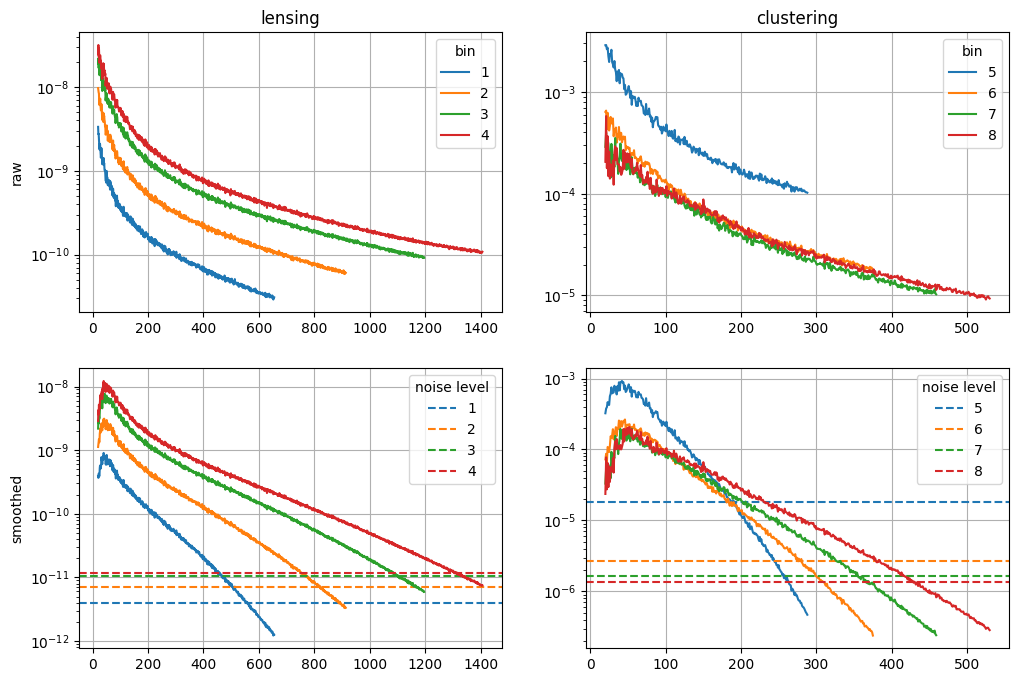

In [10]:
fig, ax = plt.subplots(figsize=(12, 8), nrows=2, ncols=2, sharex=False, sharey=False)
# colors = sns.color_palette("hls", n_z)
colors = sns.color_palette("tab10", 4)

for i in range(n_z):
    j = 0 if i < n_z_metacal else 1
    l_max = l_maxs_thresh[i]
    l_max_plot = min(l_max + 100, l_max_global)
    l = np.arange(l_min_global, l_max_plot)

    ax[0,j].plot(l, mean_cls[l_min_global:l_max_plot,i], label=i+1, color=colors[i%4])
    ax[1,j].plot(l, smooth_cls[l_min_global:l_max_plot,i], color=colors[i%4])
    # ax[1,j].axvline(l_thresholds[i], linestyle="--", label=i+1, color=colors[i%4])
    ax[1,j].axhline(cl_noise_levels[i], linestyle="--", label=i+1, color=colors[i%4])

for i in range(2):
    for j in range(2):
        ax[i,j].grid(True)
        ax[i,j].set(xscale="linear", yscale="log")
    
ax[0,0].set(title="lensing", ylabel="raw")
ax[1,0].set(ylabel="smoothed")
ax[0,1].set(title="clustering")

ax[0,0].legend(loc="upper right", title="bin")
ax[0,1].legend(loc="upper right", title="bin")

ax[1,0].legend(loc="upper right", title="noise level")
ax[1,1].legend(loc="upper right", title="noise level")

fig.savefig(f"plots/cl_noise_level_1_threshold={threshold}.png", bbox_inches="tight", dpi=100)    

In [29]:
high_pass_fac_cls[:30]

array([0.0000000e+00, 3.9032147e-06, 3.4990586e-05, 1.3913572e-04,
       3.8345135e-04, 8.5430918e-04, 1.6548132e-03, 2.9017674e-03,
       4.7222888e-03, 7.2501372e-03, 1.0621832e-02, 1.4972785e-02,
       2.0433474e-02, 2.7125707e-02, 3.5159357e-02, 4.4629209e-02,
       5.5612419e-02, 6.8166420e-02, 8.2327403e-02, 9.8109171e-02,
       1.1550297e-01, 1.3447727e-01, 1.5497881e-01, 1.7693339e-01,
       2.0024770e-01, 2.2481105e-01, 2.5049788e-01, 2.7716991e-01,
       3.0467919e-01, 3.3287016e-01], dtype=float32)

In [24]:
theta_arcmin = 30
theta_rad = theta_arcmin * np.pi / (60 * 180)
sigma = theta_rad / (2.0 * np.sqrt(2.0 * np.log(2.0)))

# l_max = scales.angle_to_ell(theta_min, arcmin=True, method="naive")
l_max = np.pi / theta_rad

low_pass_fac = np.exp(-0.5 * l_max * (l_max + 1) * sigma**2)**2

print(l_max)
print(low_pass_fac)

low_pass_fac_analytic = np.exp(-(np.pi*(np.pi + theta_rad)) / (2 * np.sqrt(2 * np.log(2)))**2)
print(low_pass_fac_analytic)

360.0
0.1678310091780065
0.1678310091780065


In [25]:
for i in range(n_z):
    l_max = l_maxs_thresh[i]
    
    print(mean_cls[l_max,i]/smooth_cls[l_max,i])


10.055125676215278
10.056267801251458
10.030078639030847
10.024438474060748
10.19887830196364
10.076228991172377
10.033991300288085
10.051716665604461


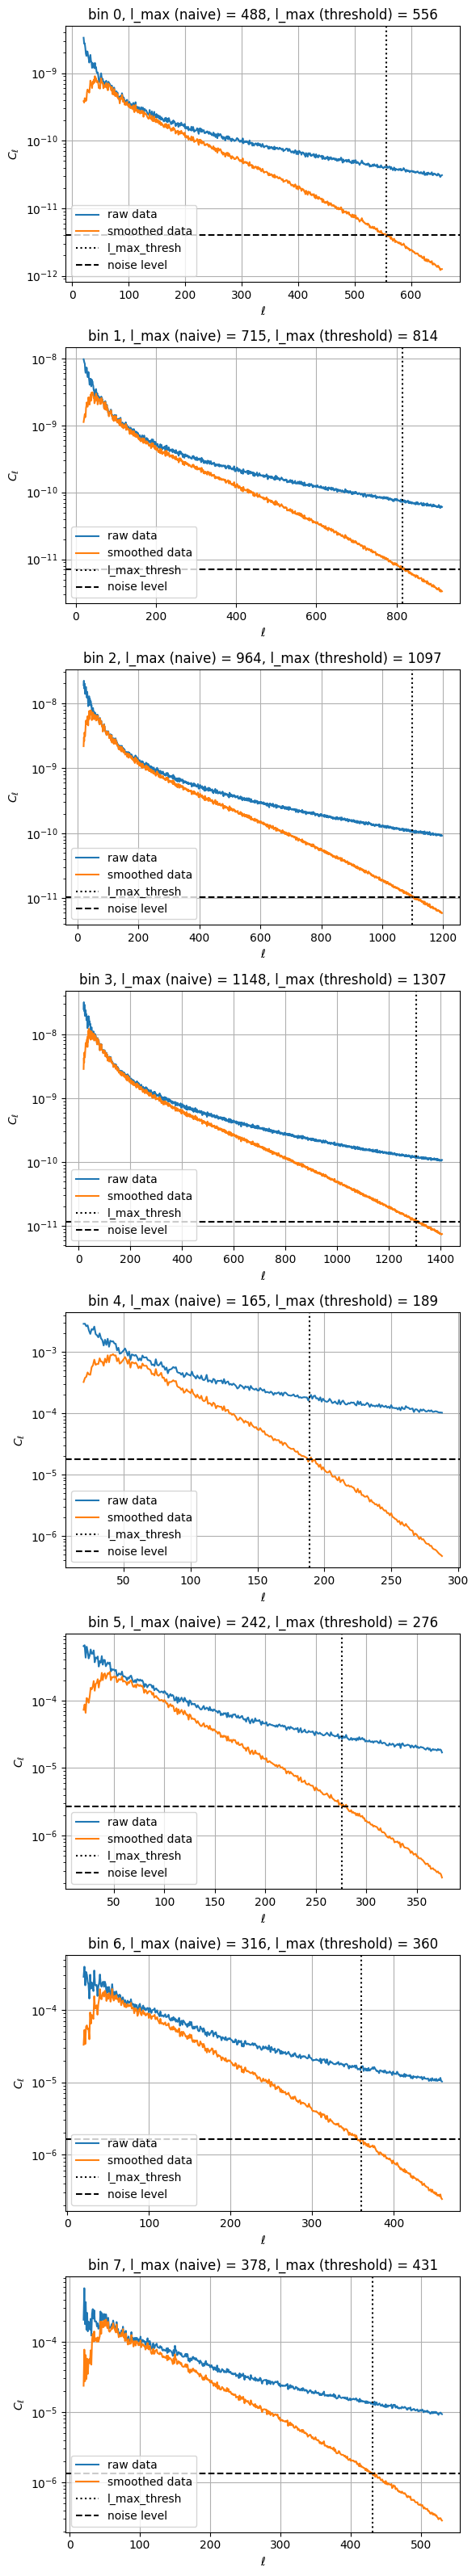

In [27]:
fig, ax = plt.subplots(figsize=(6, 4*n_z), nrows=n_z, sharex=False, sharey=False)

for i in range(n_z):
    l_max = l_maxs_thresh[i]
    l_max_plot = min(l_max + 100, l_max_global)
    l = np.arange(l_min_global, l_max_plot)
        
    ax[i].plot(l, mean_cls[l_min_global:l_max_plot,i], label="raw data")
    ax[i].plot(l, smooth_cls[l_min_global:l_max_plot,i], label="smoothed data")
    ax[i].axvline(l_maxs_thresh[i], color="k", linestyle=":", label="l_max_thresh")
    ax[i].axhline(cl_noise_levels[i], color="k", linestyle="--", label="noise level")
        
    ax[i].set(
        xscale="linear", 
        yscale="log", 
        title=f"bin {i}, l_max (naive) = {l_maxs_naive[i]}, l_max (threshold) = {l_max}", 
        xlabel=r"$\ell$", 
        ylabel=r"$C_\ell$", 
        # xlim=(, l_maxs_thresh[i] + 100),
        # ylim=(0.5 * mean_fidu_cls[32:l_max_noise,i].min(), 1.5 * mean_fidu_cls[32:l_max_noise,i].max()),
    )
    ax[i].grid(True)
    ax[i].legend(loc="lower left")
    
fig.tight_layout()
fig.savefig(f"plots/cl_noise_level_2_threshold={threshold}.png", bbox_inches="tight", dpi=100)    

### check the white noise

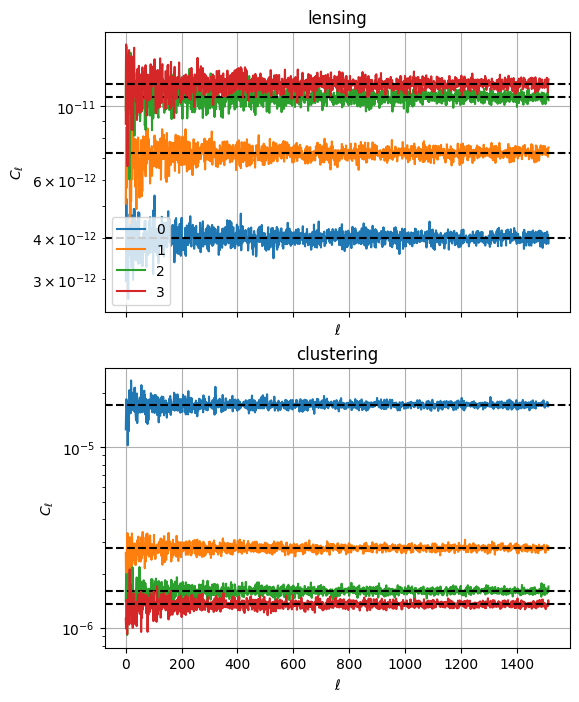

In [9]:
fig, ax = plt.subplots(figsize=(6,4*2), nrows=2, sharex=True)

rng = np.random.default_rng()
for i, sigma in enumerate(sigmas):
    noise_map = rng.normal(size=n_pix, loc=0, scale=sigma)
    noise_cls = hp.anafast(noise_map, lmax=l_max_global, pol=False, datapath=hp_datapath, use_pixel_weights=True)
    
    j = 0 if i<n_z_metacal else 1
    ax[j].plot(noise_cls[l_min_global:l_max_global], label=i)
    ax[j].axhline(cl_noise_levels[i], color="k", linestyle="--")

for i in range(2):
    ax[i].set(xscale="linear", yscale="log", xlabel=r"$\ell$", ylabel=r"$C_\ell$")
    ax[i].grid(True)
    
ax[0].set(title="lensing")
ax[1].set(title="clustering")
ax[0].legend(loc="best")

In [10]:
print(f"{threshold*100} percent")
print(f"sigmas = {sigmas}")

10.0 percent
sigmas = [1.00118499e-03 1.34439030e-03 1.63581757e-03 1.70957855e-03
 2.07311547e+00 8.33123815e-01 6.32685870e-01 5.81933646e-01]


### take the normalization of the maps into account

In [11]:
# the galaxy clustering maps don't get a normalization factor
map_normalization = np.array(conf["analysis"]["normalization"]["lensing"] + 4 * [1])
# normalized_sigmas = np.sqrt(np.array(cl_noise_levels)/map_normalization**2 / hp.nside2pixarea(n_side))
normalized_sigmas = sigmas/map_normalization

print(f"{threshold*100} percent")
print(f"normalized_sigmas = {normalized_sigmas}")

10.0 percent
normalized_sigmas = [0.11641686 0.09813068 0.0940125  0.07465408 2.07311547 0.83312381
 0.63268587 0.58193365]


10.0 percent
normalized_sigmas = [0.11641686 0.09813068 0.0940125  0.07465408 2.07311547 0.83312381
 0.63268587 0.58193365]
 
 1.0 percent
normalized_sigmas = [0.02696545 0.02255348 0.02399884 0.0438009  0.52009278 0.20640544
 0.1494878  0.13530551]
 

# smoothing layer

In [12]:
mask_dict = files.get_tomo_dv_masks(conf)
    
mask = tf.concat([mask_dict["metacal"], mask_dict["maglim"]], axis=1)
mask = mask.numpy()

smoothing_kwargs = {
    "nside": n_side,
    "indices": data_vec_pix,
    "nest": True,
    # "mask": mask,
    "fwhm": theta_fwhms,
    "arcmin": True,
    "n_sigma_support": dlss_conf["scale_cuts"]["n_sigma_support"],
    # "white_noise_sigma": normalized_sigmas,
    "white_noise_sigma": sigmas,
    "data_path": ".",
}
noisy_smoothing_layer = tf.function(HealpySmoothing(**smoothing_kwargs))

smoothing_kwargs["white_noise_sigma"] = None
smoothing_layer = tf.function(HealpySmoothing(**smoothing_kwargs))

24-09-17 01:39:39     files.py INF   Loaded the pixel file /global/u2/a/athomsen/multiprobe-simulation-forward-model/data/DESY3_pixels_v11_fiducial_512.h5 
Using the per channel smoothing repetitions [ 6  3  2  1 48 23 14 10]
Using the per channel smoothing scales sigma = [ 9.78  6.91  5.65  3.99 27.66 19.14 14.94 12.62] arcmin, fwhm = [23.03 16.28 13.29  9.4  65.13 45.08 35.17 29.73] arcmin
Successfully loaded sparse kernel indices and values from .


InternalError: Obtained a write index of 460800 which is outside of bounds of [0, 460800) [Op:SparseReduceSum]

### load maps from .tfrecords

In [ ]:
tfr_pattern = "/pscratch/sd/a/athomsen/v11desy3/v9/linear_bias/tfrecords/ficudial_backup/DESy3_fiducial_dmb_0000.tfrecord"
# tfr_pattern = "/pscratch/sd/a/athomsen/v11desy3/v9/linear_bias/tfrecords/fiducial/DESy3_fiducial_dmb_0000.tfrecord"

fidu_pipe = FiducialPipeline(
    conf=conf,
    params=[],
    with_lensing=True,
    with_clustering=True,
    with_padding=True,
    apply_norm=False,
    # apply_norm=True,
    shape_noise_scale=1.0,
    poisson_noise_scale=1.0,
)

fidu_dset = fidu_pipe.get_dset(
    tfr_pattern=tfr_pattern,
    local_batch_size=1,
    noise_indices=10,
    n_readers=1,
    examples_shuffle_buffer=None,
    n_prefetch=2,
    is_eval=True,
)

for dv, index in fidu_dset.take(1):
    dv_smooth = smoothing_layer(dv)
    dv_noisy = noisy_smoothing_layer(dv)

print(dv.shape)
print(dv_smooth.shape)
print(dv_noisy.shape)

### compare the $C_\ell$

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4*n_z), nrows=n_z, sharex=False, sharey=False)

for i in range(n_z):
    l_max = l_maxs_thresh[i]
    l_max_plot = min(l_max + 100, l_max_global)    

    raw_map = np.zeros(n_pix)
    raw_map[data_vec_pix] = dv[0,:,i]
    raw_map = hp.reorder(raw_map, n2r=True)
    raw_cls = hp.anafast(raw_map)

    smoothed_map = np.zeros(n_pix)
    smoothed_map[data_vec_pix] = dv_smooth[0,:,i]
    smoothed_map = hp.reorder(smoothed_map, n2r=True)
    smoothed_cls = hp.anafast(smoothed_map)

    noisy_map = np.zeros(n_pix)
    noisy_map[data_vec_pix] = dv_noisy[0,:,i]
    noisy_map = hp.reorder(noisy_map, n2r=True)
    noisy_cls = hp.anafast(noisy_map)

    ax[i].plot(raw_cls[l_min_global:l_max_plot], label="raw")
    ax[i].plot(smoothed_cls[l_min_global:l_max_plot], label="smoothed")
    ax[i].plot(noisy_cls[l_min_global:l_max_plot], label="noisy smoothed")

    # # smoothed on cl level
    # low_pass_fac_cls = scales.gaussian_low_pass_factor_alm(np.arange(3*n_side), theta_fwhm=theta_fwhms[i])**2
    # noisy_cls_direct = low_pass_fac_cls * raw_cls
    # noisy_cls_direct_2 = scales.cls_to_smoothed_cls(raw_cls, theta_fwhm=theta_fwhms[i])
    # ax[i].plot(noisy_cls_direct, label=r"noisy ($C_\ell$ level, $a_{\ell m}$ fac)")
    # ax[i].plot(noisy_cls_direct_2, label=r"smoothed ($C_\ell$ level, direct)")

    ax[i].axvline(l_maxs_thresh[i], color="k", linestyle="--", label="l_max (threshold)")
    probe = "lensing" if i < n_z_metacal else "clustering"
    ax[i].set(ylabel=r"$C_\ell$", xscale="linear", yscale="log", title=f"bin {i} ({probe})" )
    ax[i].grid(True)
    ax[i].legend(loc="lower left")
    
fig.savefig(f"plots/result_cl_comparison_threshold={threshold}.png", bbox_inches="tight", dpi=100)    

### compare the maps

In [ ]:
i_fid = 0

# in degrees
x_deg = 10
y_deg = x_deg
# in pixels
x_pix = 600
y_pix = x_pix
# in arcminute / pixel
reso = x_deg / x_pix * 60

rot = (90, -30, 0)

gnoms = np.zeros((3, x_pix, y_pix, n_z))

# noiseless
for i_z in range(n_z):
    hp_map = np.zeros(n_pix)
    hp_map[data_vec_pix] = dv[i_fid,:,i_z]
    gnom = hp.gnomview(hp_map, nest=True, rot=rot, reso=reso, xsize=x_pix, ysize=y_pix, return_projected_map=True, no_plot=True)
    gnoms[0, ..., i_z] = gnom

# smoothed
for i_z in range(n_z):
    hp_map = np.zeros(n_pix)
    hp_map[data_vec_pix] = dv_smooth[i_fid,:,i_z]
    gnom = hp.gnomview(hp_map, nest=True, rot=rot, reso=reso, xsize=x_pix, ysize=y_pix, return_projected_map=True, no_plot=True)
    gnoms[1, ..., i_z] = gnom
    
# noisy
for i_z in range(n_z):
    hp_map = np.zeros(n_pix)
    hp_map[data_vec_pix] = dv_noisy[i_fid,:,i_z]
    gnom = hp.gnomview(hp_map, nest=True, rot=rot, reso=reso, xsize=x_pix, ysize=y_pix, return_projected_map=True, no_plot=True)
    gnoms[2, ..., i_z] = gnom

gnoms = np.ma.masked_where(gnoms==0, gnoms)

In [ ]:
fig, ax = plt.subplots(figsize=(4*n_z, 4*3), nrows=3, ncols=n_z)

wl_min = np.array(gnoms[...,:n_z_metacal]).min()
wl_max = np.array(gnoms[...,:n_z_metacal]).max()

gc_min = np.array(gnoms[...,n_z_metacal:]).min()
gc_max = np.array(gnoms[...,n_z_metacal:]).max()

row_labels = ["raw", "smoothed", "noisy smoothed"]
for i in range(3):
    for j in range(n_z):
        # lensing
        if j < n_z_metacal:
            vmin = wl_min
            vmax = wl_max
            cmap = "viridis"
            probe = "lensing"

        # clustering
        else:
            vmin = gc_min
            vmax = gc_max
            cmap = "plasma"
            probe = "clustering"

        gnom = gnoms[i,...,j]
        im = ax[i, j].imshow(gnom, vmin=vmin, vmax=vmax, cmap=cmap)
        ax[i,j].set_xticks([])
        ax[i,j].set_yticks([])
        ax[i,j].set_aspect("equal")

        if j == 0:
            ax[i,j].set(ylabel=row_labels[i])

        if i == 0:
            ax[i,j].set(title=f"tomo bin {i_z}")

        if i == 2:
            if j == 0:
                fig.colorbar(im, ax=ax[:,:n_z_metacal], orientation="horizontal", shrink=0.7, aspect=40, pad=0.05)
            if j == 4:
                fig.colorbar(im, ax=ax[:,n_z_metacal:], orientation="horizontal", shrink=0.7, aspect=40, pad=0.05)
                
fig.savefig(f"plots/result_map_comparison_threshold={threshold}.png", bbox_inches="tight", dpi=100)    

# find combinations of theta_fwhm and noise level to result in identical l_max

### large smoothing, little noise

In [8]:
theta_fwhms = np.array([22.1, 15.1, 11.2, 9.4, 65.1, 44.5, 34.1, 28.5])
threshold = 0.01

raw_cls = np.zeros((n_examples, l_max_global+1, n_z))
for i, fidu_map in enumerate(fidu_maps):
    for j in range(fidu_map.shape[-1]):
        raw_cls[i,:,j] = hp.anafast(fidu_map[:,j], lmax=l_max_global, pol=False, datapath=hp_datapath, use_pixel_weights=True)
        
mean_cls = np.mean(raw_cls, axis=0)
smooth_cls = np.zeros_like(mean_cls)
l = np.arange(0, l_max_global+1)

with np.printoptions(precision=4, suppress=False, formatter={'float': '{:0.4e}'.format}):
    l_maxs_thresh = []
    cl_noise_levels = []
    sigmas = []
    sigmas_naive = []
    for i in range(n_z):
        # smoothing
        low_pass_fac_cls = scales.gaussian_low_pass_factor_alm(l, theta_fwhm=theta_fwhms[i], arcmin=True)**2
        smooth_cls[:,i] = low_pass_fac_cls * mean_cls[:,i]

        # determine the l_max when the Cls are suppressed by as much as the threshold
        try:
            l_max = l[low_pass_fac_cls < threshold][0]
        except IndexError:
            l_max = l_max_global
        l_maxs_thresh.append(l_max)

        # evaluate the full sky Cls at that l_max 
        cl_noise_level = smooth_cls[l_max,i]
        cl_noise_levels.append(cl_noise_level)

        # convert to a sigma of white Gaussian noise
        sigma = np.sqrt(cl_noise_level / hp.nside2pixarea(n_side))
        sigmas.append(sigma)

        sigmas_naive.append(np.sqrt(smooth_cls[l_maxs_naive[i],i] / hp.nside2pixarea(n_side)))

    l_maxs_thresh = np.array(l_maxs_thresh)
    cl_noise_levels = np.array(cl_noise_levels)
    sigmas = np.array(sigmas)

    print(f"\nthreshold = {threshold*100}%")
    print(f"l_maxs_thresh = {l_maxs_thresh}")
    print(f"cl_noise_levels = {cl_noise_levels}")
    print(f"sigmas = {sigmas}")



threshold = 1.0%
l_maxs_naive = [ 488  715  964 1148  165  242  316  378]
l_maxs_thresh = [ 786 1150 1535 1535  267  390  509  610]
cl_noise_levels = [2.1298e-13 3.6763e-13 7.0023e-13 4.0398e-12 1.0268e-06 1.7713e-07
 9.1055e-08 7.4034e-08]
sigmas = [2.3090e-04 3.0336e-04 4.1867e-04 1.0056e-03 5.0699e-01 2.1057e-01
 1.5098e-01 1.3614e-01]


### large noise, little smoothing

In [17]:
theta_fwhms = 0.707 * np.array([22.1, 15.1, 11.2, 9.4, 65.1, 44.5, 34.1, 28.5])
threshold = 0.1

raw_cls = np.zeros((n_examples, l_max_global+1, n_z))
for i, fidu_map in enumerate(fidu_maps):
    for j in range(fidu_map.shape[-1]):
        raw_cls[i,:,j] = hp.anafast(fidu_map[:,j], lmax=l_max_global, pol=False, datapath=hp_datapath, use_pixel_weights=True)
        
mean_cls = np.mean(raw_cls, axis=0)
smooth_cls = np.zeros_like(mean_cls)
l = np.arange(0, l_max_global+1)

with np.printoptions(precision=4, suppress=False, formatter={'float': '{:0.4e}'.format}):
    l_maxs_thresh = []
    cl_noise_levels = []
    sigmas = []
    sigmas_naive = []
    for i in range(n_z):
        # smoothing
        low_pass_fac_cls = scales.gaussian_low_pass_factor_alm(l, theta_fwhm=theta_fwhms[i], arcmin=True)**2
        smooth_cls[:,i] = low_pass_fac_cls * mean_cls[:,i]

        # determine the l_max when the Cls are suppressed by as much as the threshold
        try:
            l_max = l[low_pass_fac_cls < threshold][0]
        except IndexError:
            l_max = l_max_global
        l_maxs_thresh.append(l_max)

        # evaluate the full sky Cls at that l_max 
        cl_noise_level = smooth_cls[l_max,i]
        cl_noise_levels.append(cl_noise_level)

        # convert to a sigma of white Gaussian noise
        sigma = np.sqrt(cl_noise_level / hp.nside2pixarea(n_side))
        sigmas.append(sigma)

        sigmas_naive.append(np.sqrt(smooth_cls[l_maxs_naive[i],i] / hp.nside2pixarea(n_side)))

    l_maxs_thresh = np.array(l_maxs_thresh)
    cl_noise_levels = np.array(cl_noise_levels)
    sigmas = np.array(sigmas)

    print(f"\nthreshold = {threshold*100}%")
    print(f"l_maxs_thresh = {l_maxs_thresh}")
    print(f"cl_noise_levels = {cl_noise_levels}")
    print(f"sigmas = {sigmas}")



threshold = 10.0%
l_maxs_naive = [ 488  715  964 1148  165  242  316  378]
l_maxs_thresh = [ 786 1151 1535 1535  267  390  510  610]
cl_noise_levels = [2.1366e-12 3.8061e-12 6.6917e-12 1.9810e-11 1.0391e-05 1.7749e-06
 8.7472e-07 7.4620e-07]
sigmas = [7.3134e-04 9.7611e-04 1.2943e-03 2.2269e-03 1.6128e+00 6.6656e-01
 4.6794e-01 4.3220e-01]
